In [1]:
from functools import partial

import jax
from jax import numpy as jnp
import numpy as np
import einops

import equinox as eqx
from equinox.nn import Linear

from typing import Optional
from jaxtyping import Float, Array, PRNGKeyArray

import matplotlib.pyplot as plt

from jepax.data import build_dataset
from jepax.model.transformer import PositionalEncoding2D
from jepax.model.masker import IJEPAMasker, patchify, unpatchify, visualize_mask
from jepax.model.ijepa import IJEPA, IJEPAEncoder, IJEPAPredictor

dataloader, _, _, _ = build_dataset("CIFAR10", data_dir="~/data")
x, y = next(iter(dataloader))

show_mask = lambda x, mask: visualize_mask(x, mask, 2, 16)

/Users/anton/source/jepax/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


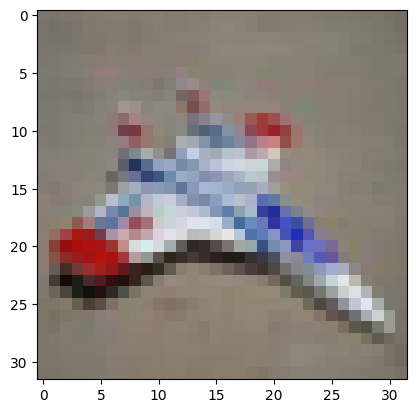

In [2]:
x_in = x[-2]
plt.imshow(x_in)

## Full Model

In [3]:
key = jax.random.PRNGKey(0)
key_e, key_p, key_m = jax.random.split(key, 3)
M = 4

masker = IJEPAMasker(32, 32, 2, ctx_scale=0.8, ctx_aspect=1.0, pred_scale=0.2, pred_aspect=(0.9, 1.2))

#@partial(jax.jit, static_argnums=(1,2))
def create_mask(key, M, flatten):
    return masker(key, M, flatten=flatten)

mask_ctx, mask_pred = create_mask(key_m, M, True)

encoder = IJEPAEncoder(
    key=key_e,
    num_channels=3,
    patch_size=2,
    dim=64,
    num_head=4,
    num_layers=1,
    img_size=32
)

predictor = IJEPAPredictor(
    key=key_p,
    latent_dim=32,
    grid_size=16,
    dim=64,
    num_head=2,
    num_layers=1
)

model = IJEPA(encoder, predictor)

0.2


/Users/anton/source/jepax/jepax/model/transformer.py:227: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.pe = PositionalEncoding2D(
/Users/anton/source/jepax/jepax/model/transformer.py:223: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.pe = PositionalEncoding(dim=dim, seq_len=seq_len)
/Users/anton/source/jepax/jepax/model/ijepa.py:250: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.pe = PositionalEncoding2D(dim=latent_dim, seq_len=seq_len, grid_size=grid_size)


In [4]:
mask_enc = ~(~mask_ctx | jnp.any(mask_pred, axis=0))
z, z_full, z_pred, mask_idx = model(key_e, x_in, mask_enc, mask_pred, num_pad=64)

In [5]:
target = z_full[mask_idx][mask_idx > 0]
target.shape

(36, 64)

In [6]:
pred = z_pred[mask_idx > 0]
pred.shape

(36, 64)

In [7]:
def loss_ijepa(model, x, mask_enc, mask_pred, num_pad=64):
    _, z_full, z_pred, mask_idx = model(key_e, x, mask_enc, mask_pred, num_pad=num_pad)

    target = z_full[mask_idx][mask_idx > 0]
    pred = z_pred[mask_idx > 0]

    return jnp.mean(jnp.sum((target - pred)**2, axis=-1), axis=0)

loss = loss_ijepa(model, x_in, mask_enc, mask_pred)
loss

Array(76.25415, dtype=float32)

In [8]:
encoder_ema = model.encoder
encoder_ema

IJEPAEncoder(
  embed=PatchEmbedding(
    linear=Linear(
      weight=f32[64,12],
      bias=f32[64],
      in_features=12,
      out_features=64,
      use_bias=True
    ),
    patch_size=2
  ),
  transformer=Transformer(
    blocks=[
      TransformerBlock(
        attn=Attention(
          qkv_proj=Linear(
            weight=f32[192,64],
            bias=f32[192],
            in_features=64,
            out_features=192,
            use_bias=True
          ),
          out_proj=Linear(
            weight=f32[64,64],
            bias=f32[64],
            in_features=64,
            out_features=64,
            use_bias=True
          ),
          num_head=4,
          dim=64,
          causal=True
        ),
        ff=FeedForward(
          linear1=Linear(
            weight=f32[192,64],
            bias=f32[192],
            in_features=64,
            out_features=192,
            use_bias=True
          ),
          linear2=Linear(
            weight=f32[64,192],
            bias

In [9]:
model = jax.tree.map(
    jnp.zeros_like,
    model,
    is_leaf=eqx.is_array
)

encoder_new = jax.tree.map(
    lambda x, y: 0.9 * x + 0.1 * y,
    encoder_ema, model.encoder
)

model = eqx.tree_at(lambda m: m.encoder, model, encoder_new)



In [10]:
model.encoder.embed.linear.weight

Array([[-0.22252743, -0.07143622, -0.033312  , -0.14716972,  0.06466201,
        -0.07173844,  0.08466352, -0.03343613, -0.02076749, -0.10784282,
        -0.1513463 , -0.11004018],
       [-0.03256874,  0.11639807,  0.15016875,  0.0280243 ,  0.08019594,
         0.1190812 ,  0.13891111,  0.1839094 ,  0.23742513,  0.2016426 ,
         0.22841096, -0.0349157 ],
       [-0.15483207,  0.19960773,  0.1697561 ,  0.0099333 , -0.01839836,
         0.14523828, -0.2122161 , -0.21086091,  0.11822167, -0.12892629,
        -0.18797731, -0.0534328 ],
       [ 0.0326046 ,  0.00624088, -0.01768211,  0.13775977, -0.17534515,
        -0.12044339,  0.1973263 ,  0.07793477,  0.2011413 , -0.22479868,
         0.23507212, -0.18944907],
       [ 0.1254996 , -0.24725015,  0.20793577, -0.1606612 ,  0.1663114 ,
        -0.06207434,  0.12429469, -0.16060118, -0.10993736, -0.08780161,
        -0.13598616,  0.23305786],
       [ 0.09999025,  0.16703384, -0.24595214,  0.19486909,  0.10080362,
        -0.00365563, -

In [ ]:
valid = mask_idx >= 0  # (B, num_pad)
safe_idx = jnp.where(valid, mask_idx, 0)  # avoid OOB indexing
target = jax.vmap(lambda z, idx: z[idx])(z_full, safe_idx)  # (B, num_pad, D)

mse = jnp.sum((target - z_pred) ** 2, axis=-1)  # (B, num_pad)
loss = jnp.sum(mse * valid) / jnp.sum(valid)  # only count valid positions

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 256: axis 0 of argument z of type float32[256,64];
  * one axis had size 64: axis 0 of argument idx of type int32[64]

In [14]:
safe_idx

Array([ 65,  66,  67,  81,  82,  83,  97,  98,  99, 144, 145, 146, 160,
       161, 162, 176, 177, 178, 184, 185, 186, 200, 201, 202, 216, 217,
       218, 177, 178, 179, 193, 194, 195, 209, 210, 211,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],      dtype=int32)

## MSE